# Lab 6.02 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 2: Flemish agricultural and horticultural businesses

1. Use the dataset agriculture flanders.csv. The file contains data about agricultural and horticultural businesses in Flanders

    Source: Departement Landbouw en Visserij op basis van StatBel

In [5]:
farms = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/agriculture%20flanders.csv', delimiter = ";", decimal=',')
# Show the first few records of the Data Frame
farms.head()

,year,number_of_farms,average_area_per_farm_(ha)
0,1980,75706,8.38
1,1981,73292,8.58
2,1982,71255,8.79
3,1983,69807,8.94
4,1984,68083,9.15


2. What are the datatypes for each of the columns.

In [7]:
farms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        41 non-null     int64  
 1   number_of_farms             41 non-null     int64  
 2   average_area_per_farm_(ha)  41 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 1.1 KB


3. Draw a scatter plot of the number of farms versus the year.


<Axes: xlabel='year', ylabel='number_of_farms'>

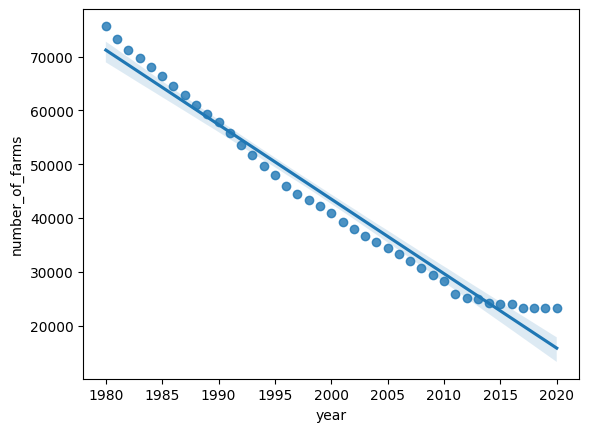

In [11]:
sns.regplot(farms, x='year', y='number_of_farms')

4. Is there a positive / negative relationship between year and number_of_farms?

    $R = -0.9861066349492859$

In [14]:
np.corrcoef(x=farms['year'], y=farms['number_of_farms'])[0][1]

np.float64(-0.9861066349492859)

6. Is there a strong relationship between year and 'number_of_farms'?

    $R^2 = 0.9724062954910041$

In [15]:
np.corrcoef(x=farms['year'], y=farms['number_of_farms'])[0][1]**2

np.float64(0.9724062954910041)

In [ ]:
# R<0 -> Dalend verband
# R ~0.98 -> sterk verband
# R**2 ~ 0.97 -> 97% van de variantie van de afh var is verklaard door de regressielijn = sterk lineair verband

7. Draw a scatter plot of the 'average_area_per_farm_(ha)' versus the year.

<Axes: xlabel='year', ylabel='average_area_per_farm_(ha)'>

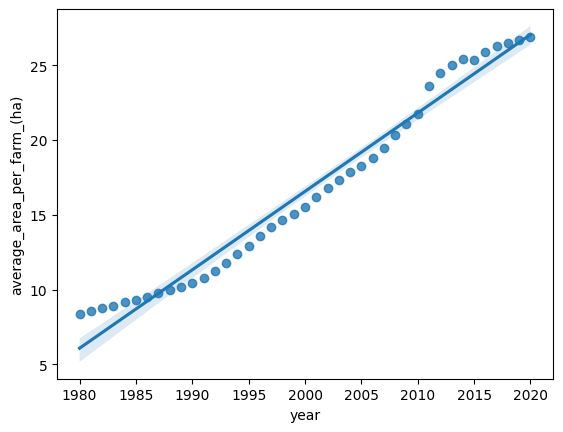

In [16]:
sns.regplot(farms, x='year', y='average_area_per_farm_(ha)')

8. What will be the 'average_area_per_farm_(ha)' in 2035?

Average area in 2035 = 34.91987804878045

In [37]:
from sklearn.linear_model import LinearRegression

X = farms['year'].values.reshape(-1,1)
y = farms['average_area_per_farm_(ha)']

model = LinearRegression().fit(X,y)
model.predict(np.array(2035).reshape(-1,1))

array([34.91987805])

In [39]:
b1,b0 = np.polyfit(x=farms['year'], y=farms['average_area_per_farm_(ha)'], deg=1)
b1,b0

(np.float64(0.5242334494773592), np.float64(-1031.8951916376452))

In [40]:
y = b0 + b1*2035
y

np.float64(34.919878048780674)

8. Calculate the total agricultural area for each year.   
Calculate for each year the change of the total area relative to 1980.  
Make a plot.

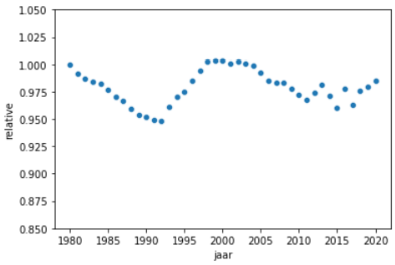


In [42]:
farms['total_agricultural_area'] = farms['number_of_farms']*farms['average_area_per_farm_(ha)']
farms.head()

,year,number_of_farms,average_area_per_farm_(ha),total_agricultural_area
0,1980,75706,8.38,634416.28
1,1981,73292,8.58,628845.36
2,1982,71255,8.79,626331.45
3,1983,69807,8.94,624074.58
4,1984,68083,9.15,622959.45


In [54]:
year_1980 = farms[farms['year']==1980]
total_area_year_1980 = year_1980.iloc[0,3]

In [55]:
total_area_year_1980

np.float64(634416.28)

In [58]:
farms['rel_to_1980'] = (farms['total_agricultural_area'] - total_area_year_1980) / total_area_year_1980
farms.head()

,year,number_of_farms,average_area_per_farm_(ha),total_agricultural_area,rel_to_1980
0,1980,75706,8.38,634416.28,0.000000
1,1981,73292,8.58,628845.36,-0.008781
2,1982,71255,8.79,626331.45,-0.012744
3,1983,69807,8.94,624074.58,-0.016301
4,1984,68083,9.15,622959.45,-0.018059


In [59]:
farms.tail()

,year,number_of_farms,average_area_per_farm_(ha),total_agricultural_area,rel_to_1980
36,2016,23981,25.87,620388.47,-0.022111
37,2017,23225,26.31,611049.75,-0.036832
38,2018,23361,26.50,619066.50,-0.024195
39,2019,23318,26.66,621657.88,-0.020110
40,2020,23225,26.90,624752.50,-0.015233


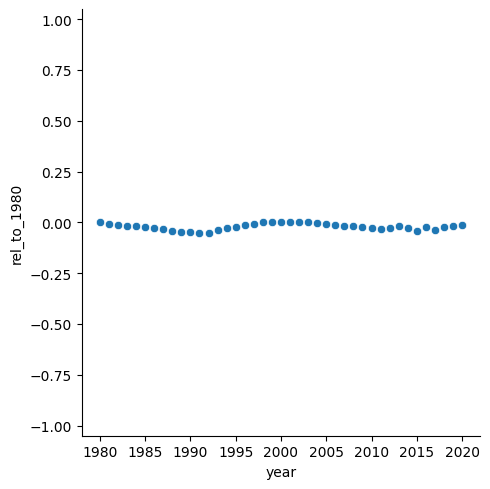

In [68]:
p = sns.relplot(x=farms['year'], y=farms['rel_to_1980'])
p.set(ylim=(-1.05,1.05))
p